In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


class DenseLayer:
    def __init__(self, units=1, activation='relu'):
        self.units = units
        self.activation = activation.lower()
        self.w = None
        self.b = None
        self.input = None
        self.z = None

    def init_weights(self, fan_in):
        if self.activation in ['relu', 'leaky_relu']:
            std = np.sqrt(2.0 / fan_in)
        else:
            std = np.sqrt(1.0 / fan_in)

        self.w = np.random.normal(0.0, std, (fan_in, self.units))
        self.b = np.zeros(self.units)

    def forward(self, x):
        if self.w is None:
            self.init_weights(x.shape[-1])

        self.z = x @ self.w + self.b

        if self.activation == 'relu':
            return np.maximum(0, self.z)

        elif self.activation == 'leaky_relu':
            return np.maximum(0.01 * self.z, self.z)

        elif self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-np.clip(self.z, -500, 500)))

        elif self.activation == 'tanh':
            return np.tanh(self.z)

        elif self.activation == 'softmax':
            exp_z = np.exp(self.z - np.max(self.z, axis=1, keepdims=True))
            return exp_z / np.sum(exp_z, axis=1, keepdims=True)

        elif self.activation == 'linear':
            return self.z

        else:
            raise ValueError(f"Неизвестная активация: {self.activation}")

    def derivative(self, a):
        if self.activation == 'relu':
            return (self.z > 0).astype(float)

        elif self.activation == 'leaky_relu':
            return (self.z > 0).astype(float) + 0.01 * (self.z <= 0).astype(float)

        elif self.activation == 'sigmoid':
            return a * (1 - a)

        elif self.activation == 'tanh':
            return 1 - a**2

        elif self.activation == 'linear':
            return np.ones_like(a)

        elif self.activation == 'softmax':
            return np.ones_like(a)

        return np.ones_like(a)


class Input:
    def __init__(self, shape=None):
        self.shape = shape

    def forward(self, x):
        if self.shape is not None:
            expected = self.shape if isinstance(self.shape, tuple) else (self.shape,)
            if x.shape[1:] != expected:
                x = x.reshape((x.shape[0],) + expected)
        return x


class Dropout:
    def __init__(self, rate=0.5):
        self.rate = rate
        self.mask = None
        self.training = True

    def forward(self, x):
        if not self.training:
            return x
        self.mask = (np.random.rand(*x.shape) > self.rate) / (1 - self.rate)
        return x * self.mask


class Sequential:
    def __init__(self, layers):
        self.layers = layers
        self.history = []
        self.loss_fn = None
        self.loss_deriv = None
        self.l1 = 0
        self.l2 = 0

    def compile(self, loss='mse', l1=0.0, l2=0.0):
        self.l1 = l1
        self.l2 = l2
        self.loss = loss.lower()

        if self.loss == 'mse':
            self.loss_fn = lambda y, p: 0.5 * np.sum((p - y) ** 2)
            self.loss_deriv = lambda y, p: (p - y)

        elif self.loss == 'mae':
            self.loss_fn = lambda y, p: np.mean(np.abs(p - y))
            self.loss_deriv = lambda y, p: np.sign(p - y)

        elif self.loss == 'binary_crossentropy':
            eps = 1e-8
            self.loss_fn = lambda y, p: -np.mean(
                y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)
            )
            self.loss_deriv = lambda y, p: (p - y)

        elif self.loss == 'categorical_crossentropy':
            eps = 1e-8
            self.loss_fn = lambda y, p: -np.mean(np.sum(y * np.log(p + eps), axis=1))
            self.loss_deriv = lambda y, p: (p - y)

        else:
            raise ValueError(f"Неизвестная функция потерь: {loss}")

    def forward(self, x):
        out = x
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def fit(self, x_input, y_input, epochs=100, alpha=0.001, batch_size=32,
            clip_value=5.0, adaptive_alpha=False, Ee=1e-3):
        x_input = np.asarray(x_input, dtype=np.float32)
        y_input = np.asarray(y_input, dtype=np.float32).reshape(-1, 1)

        n_samples = x_input.shape[0]
        self.history = []

        for epoch in range(epochs):
            indices = np.random.permutation(n_samples)
            x_shuffled = x_input[indices]
            y_shuffled = y_input[indices]

            for i in range(0, n_samples, batch_size):
                x = x_shuffled[i:i + batch_size]
                y = y_shuffled[i:i + batch_size]

                if adaptive_alpha:
                    alpha_t = 1.0 / (1 + np.sum(x ** 2))
                else:
                    alpha_t = alpha

                activations = [x]
                for layer in self.layers:
                    if isinstance(layer, Dropout):
                        layer.training = True
                    activations.append(layer.forward(activations[-1]))

                pred = activations[-1]
                delta = self.loss_deriv(y, pred)

                for l in range(len(self.layers) - 1, -1, -1):
                    layer = self.layers[l]

                    if isinstance(layer, Input):
                        continue

                    if isinstance(layer, Dropout):
                        delta *= layer.mask
                        continue

                    a_prev = activations[l]
                    da = layer.derivative(activations[l + 1])
                    delta *= da

                    grad_w = (a_prev.T @ delta) / x.shape[0]
                    grad_b = np.mean(delta, axis=0)

                    if self.l2:
                        grad_w += 2 * self.l2 * layer.w
                    if self.l1:
                        grad_w += self.l1 * np.sign(layer.w)

                    grad_w = np.clip(grad_w, -clip_value, clip_value)
                    grad_b = np.clip(grad_b, -clip_value, clip_value)

                    previous_delta = delta @ layer.w.T
                    layer.w -= alpha_t * grad_w
                    layer.b -= alpha_t * grad_b
                    delta = previous_delta

            epoch_loss = self.loss_fn(y_input, self.predict(x_input))
            self.history.append(epoch_loss)

            if epoch % 10 == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch:4d} | Es = {epoch_loss:.6f}")

            if epoch_loss <= Ee:
                print(f"Достигнут критерий остановки: {epoch_loss} <= {Ee}")
                return epoch + 1, True

        return epochs, False

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)

        if X.ndim == 1:
            X = X.reshape(1, -1)

        for layer in self.layers:
            if isinstance(layer, Dropout):
                layer.training = False

        return self.forward(X)

    def evaluate(self, X, Y):
        Y = np.asarray(Y, dtype=np.float32).reshape(-1, 1)
        preds = self.predict(X)
        loss = self.loss_fn(Y, preds) if self.loss_fn is not None else None

        last_activation = getattr(self.layers[-1], "activation", None)
        if last_activation == "sigmoid":
            y_hat = (preds >= 0.5).astype(np.float32)
            acc = np.mean(y_hat == Y)
        else:
            acc = None

        return loss, acc

### Многослойный персептрон 

--- Обучение MLP ---
Epoch    0 | Es = 0.501791
Epoch   10 | Es = 0.500423
Epoch   20 | Es = 0.500187
Epoch   30 | Es = 0.500185
Epoch   40 | Es = 0.500151
Epoch   50 | Es = 0.500144
Epoch   60 | Es = 0.500218
Epoch   70 | Es = 0.500134
Epoch   80 | Es = 0.500115
Epoch   90 | Es = 0.500146
Epoch  100 | Es = 0.500176
Epoch  110 | Es = 0.500049
Epoch  120 | Es = 0.500025
Epoch  130 | Es = 0.500005
Epoch  140 | Es = 0.500015
Epoch  150 | Es = 0.499986
Epoch  160 | Es = 0.499958
Epoch  170 | Es = 0.499940
Epoch  180 | Es = 0.499890
Epoch  190 | Es = 0.499862
Epoch  200 | Es = 0.499838
Epoch  210 | Es = 0.499795
Epoch  220 | Es = 0.499762
Epoch  230 | Es = 0.499759
Epoch  240 | Es = 0.499671
Epoch  250 | Es = 0.499623
Epoch  260 | Es = 0.499583
Epoch  270 | Es = 0.499587
Epoch  280 | Es = 0.499450
Epoch  290 | Es = 0.499389
Epoch  300 | Es = 0.499310
Epoch  310 | Es = 0.499219
Epoch  320 | Es = 0.499112
Epoch  330 | Es = 0.499003
Epoch  340 | Es = 0.498882
Epoch  350 | Es = 0.498748
Epoch  

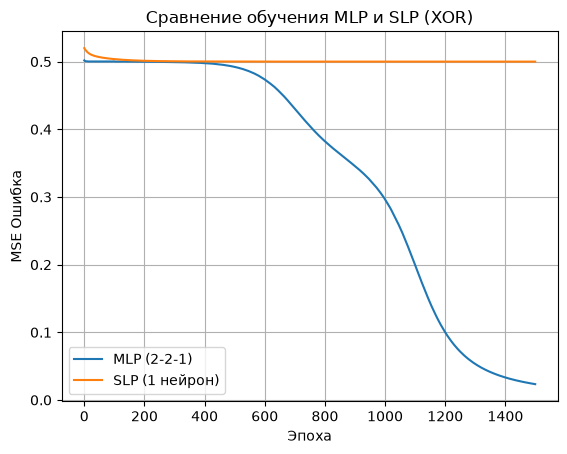

In [7]:
c0, c1 = -4.0, -9.0
x = np.array([[c0, c0], [c0, c1], [c1, c0], [c1, c1]], dtype=np.float32)
# Сигмоида воспроизводит [0; 1], поэтому классы кодируются для обучения.
x_norm = (x - c0) / (c1 - c0)
y = np.array([0, 1, 1, 0], dtype=np.float32)

print("--- Обучение MLP ---")
mlp = Sequential([
    Input(),
    DenseLayer(units=2, activation="sigmoid"), 
    DenseLayer(units=1, activation="sigmoid")   
])
mlp.compile(loss="mse") 
mlp.fit(x_norm, y, epochs=1500, alpha=0.5, batch_size=1, Ee=0.01)

print("\n--- Обучение SLP ---")
slp = Sequential([
    Input(),
    DenseLayer(units=1, activation="sigmoid") 
])
slp.compile(loss="mse")
slp.fit(x_norm, y, epochs=1500, alpha=0.1, batch_size=1)

plt.plot(mlp.history, label='MLP (2-2-1)')
plt.plot(slp.history, label='SLP (1 нейрон)')
plt.xlabel("Эпоха")
plt.ylabel("MSE Ошибка")
plt.title("Сравнение обучения MLP и SLP (XOR)")
plt.legend()
plt.grid(True)
plt.show()


--- Режим функционального тестирования ---
Для завершения работы введите 'q'
Выход сети (ŷ): -6.0383 | Ближе к классу: -4



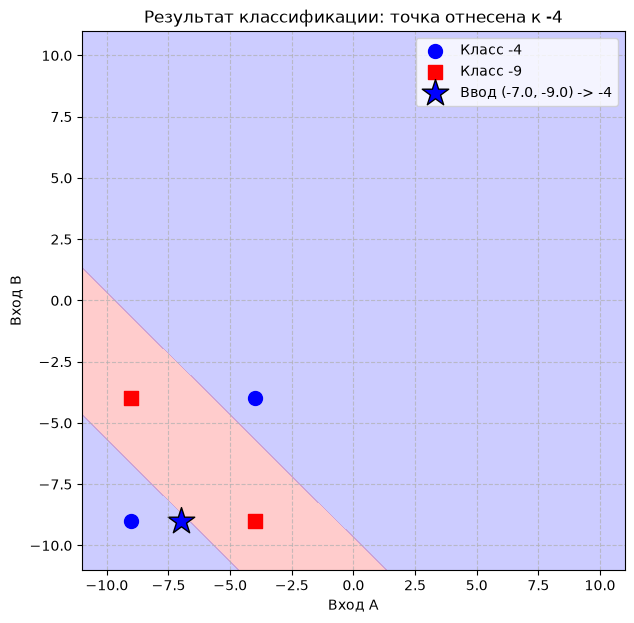

Выход сети (ŷ): -4.4161 | Ближе к классу: -4

Тестирование завершено.


In [ ]:
def functional_testing_interactive(model, c0=-4, c1=-9):
    print("\n--- Режим функционального тестирования ---")
    print("Для завершения работы введите 'q'")

    X_c0 = np.array([[c0, c0], [c1, c1]])
    X_c1 = np.array([[c0, c1], [c1, c0]])

    xx, yy = np.meshgrid(np.linspace(-11, 11, 100), np.linspace(-11, 11, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_norm = (grid - c0) / (c1 - c0)
    preds = model.predict(grid_norm).flatten()
    Z = np.where(preds < 0.5, c0, c1).reshape(xx.shape)

    plt.ion()
    fig, ax = plt.subplots(figsize=(7, 7))

    while True:
        user_input = input("Введите пару чисел A и B из диапазона [-10; 10] через пробел: ")

        if user_input.lower() == 'q':
            print("Тестирование завершено.")
            plt.ioff()
            plt.close()
            break

        try:
            a_str, b_str = user_input.split()
            A, B = float(a_str), float(b_str)

            if not (-10 <= A <= 10) or not (-10 <= B <= 10):
                print("Ошибка: Введенные числа лежат вне диапазона [-10; 10].")
                continue

            test_x = (np.array([[A, B]], dtype=np.float32) - c0) / (c1 - c0)
            pred = model.predict(test_x)[0][0]
            y_hat = c0 + pred * (c1 - c0)

            if abs(y_hat - c0) <= abs(y_hat - c1):
                predicted_class = c0
                point_color = 'blue'
            else:
                predicted_class = c1
                point_color = 'red'

            print(f"Выход сети (ŷ): {y_hat:.4f} | Ближе к классу: {predicted_class}\n")

            ax.clear()
            ax.contourf(
                xx, yy, Z, alpha=0.2,
                levels=[min(c0, c1) - 1, (c0 + c1) / 2, max(c0, c1) + 1],
                colors=['red', 'blue']
            )
            ax.scatter(X_c0[:, 0], X_c0[:, 1], c='blue', marker='o', s=100, label=f'Класс {c0}')
            ax.scatter(X_c1[:, 0], X_c1[:, 1], c='red', marker='s', s=100, label=f'Класс {c1}')
            ax.scatter(A, B, c=point_color, marker='*', s=400, edgecolor='black',
                       label=f'Ввод ({A}, {B}) -> {predicted_class}')
            ax.set_xlim(-11, 11)
            ax.set_ylim(-11, 11)
            ax.set_xlabel('Вход A')
            ax.set_ylabel('Вход B')
            ax.set_title(f'Результат классификации: точка отнесена к {predicted_class}')
            ax.grid(True, linestyle='--', alpha=0.7)
            ax.legend()
            fig.canvas.draw()
            fig.canvas.flush_events()
            plt.pause(0.1)

        except ValueError:
            print("Ошибка: Некорректный ввод. Введите два числа через пробел.\n")


functional_testing_interactive(mlp)